# Метод Ньютона для нелинейной краевой задачи: задача Брату

В баллистическом примере мы подбирали один угол по одной невязке. Теперь неизвестным будет целый вектор значений функции на сетке. Метод Ньютона одновременно исправляет все его компоненты.

План: записать разностную схему, построить вектор невязки и якобиан, найти два решения одной задачи, проверить точность по известному решению и проследить ветви при изменении параметра.

## 1. Постановка задачи

Рассмотрим безразмерную краевую задачу Брату:

$$
\left\{
\begin{aligned}
u''(x)+\lambda e^{u(x)}&=0,\qquad x\in[0,1],\\
u(0)&=0,\\
u(1)&=0.
\end{aligned}
\right.
$$

Её можно интерпретировать как стационарный нагрев слоя: границы поддерживаются при заданной температуре, а интенсивность внутреннего тепловыделения экспоненциально растёт с температурой. Здесь $u$ — безразмерное превышение температуры, $\lambda>0$ — параметр интенсивности тепловыделения. Это идеализированная модель.

Начнём с $\lambda=1$. При таком параметре у задачи есть два решения. Постараемся найти оба.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

np.set_printoptions(precision=6, suppress=True)

Lambda = 1.0
N = 100  # Число интервалов; внутренних неизвестных N - 1.
x = np.linspace(0.0, 1.0, N + 1)
h = 1.0 / N
RootTol = 1e-9  # Допуск на максимальный модуль компоненты разностной невязки.

## 2. От функции к вектору неизвестных

Введём равномерную сетку $x_i=ih$, где $h=1/N$, $i=0,\ldots,N$. Граничные значения $u_0=u_N=0$ известны. Неизвестны только внутренние значения:

$$U=(u_1,\ldots,u_{N-1})^{\mathsf T}\in\mathbb R^{N-1}.$$

Заменим вторую производную центральной разностью. Получим систему:

$$F_i(U)=\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}+\lambda e^{u_i}=0,
\qquad i=1,\ldots,N-1.$$

Таким образом, $F:\mathbb R^{N-1}\to\mathbb R^{N-1}$. Один вектор $U$ задаёт один приближённый профиль на всём отрезке. Нулевая компонента $F_i$ означает выполнение разностного уравнения в узле $i$.

Число уравнений совпадает с числом неизвестных. Граничные значения уже подставлены в первое и последнее уравнения.

In [19]:
def residual(U, lam):
    """Вектор разностной невязки для внутренних узлов; u(0) = u(1) = 0."""
    h = 1.0 / (len(U) + 1)
    full = np.r_[0.0, U, 0.0]
    with np.errstate(over="ignore", invalid="ignore"):
        return (full[:-2] - 2*full[1:-1] + full[2:]) / h**2 + lam*np.exp(U)


def residual_norm(U, lam):
    """Максимальный модуль компоненты невязки."""
    values = residual(U, lam)
    return np.max(np.abs(values)) if np.all(np.isfinite(values)) else np.inf

## 3. Многомерный шаг Ньютона

Линеаризуем векторную функцию около текущего приближения:

$$F(U+\Delta U)\approx F(U)+J(U)\Delta U,$$

где $J_{ij}=\partial F_i/\partial u_j$ — матрица Якоби. Поправку находим из линейной системы:

$$\boxed{J(U^{(k)})\Delta U^{(k)}=-F(U^{(k)})},\qquad
U^{(k+1)}=U^{(k)}+\Delta U^{(k)}.$$

Это многомерный аналог деления на производную в скалярной формуле. В программе нужно **решать линейную систему**, а не вычислять обратную матрицу.

Для нашей схемы:

$$J_{ii}=-\frac{2}{h^2}+\lambda e^{u_i},\qquad
J_{i,i-1}=J_{i,i+1}=\frac{1}{h^2}.$$

Остальные элементы нулевые. Якобиан трёхдиагональный: уравнение в узле зависит только от значения в этом узле и двух соседних.

Для наглядности ниже собираем обычную плотную матрицу и вызываем `np.linalg.solve`. На больших сетках стоит хранить только три диагонали и использовать, например, `scipy.linalg.solve_banded`.

In [20]:
def jacobian(U, lam):
    """Аналитический якобиан разностной невязки."""
    h = 1.0 / (len(U) + 1)
    diagonal = -2.0 / h**2 + lam*np.exp(U)
    off_diagonal = np.full(len(U) - 1, 1.0 / h**2)
    return (np.diag(diagonal)
            + np.diag(off_diagonal, 1)
            + np.diag(off_diagonal, -1))

### Один шаг на трёх неизвестных

Возьмём четыре интервала, то есть три внутренних узла, и начальный профиль $U^{(0)}=0$. Напечатаем невязку, якобиан и поправку. После одного шага невязка обычно ещё не равна нулю: линеаризация была приближённой.

In [21]:
U_coarse = np.zeros(3)
F_coarse = residual(U_coarse, Lambda)
J_coarse = jacobian(U_coarse, Lambda)
delta_coarse = np.linalg.solve(J_coarse, -F_coarse)

print("F(U⁽⁰⁾) =", F_coarse)
print("J(U⁽⁰⁾) =\n", J_coarse)
print("Поправка ΔU =", delta_coarse)
print("Невязка после шага =", residual(U_coarse + delta_coarse, Lambda))

F(U⁽⁰⁾) = [1. 1. 1.]
J(U⁽⁰⁾) =
 [[-31.  16.   0.]
 [ 16. -31.  16.]
 [  0.  16. -31.]]
Поправка ΔU = [0.104677 0.140312 0.104677]
Невязка после шага = [0.005675 0.010321 0.005675]


## 4. Итерационный алгоритм

Повторяем построение якобиана и решение линейной системы, пока $\|F(U)\|_\infty$ не станет меньше допуска.

Для первой демонстрации используем обычный шаг Ньютона. В функции также предусмотрено уменьшение шага:

$$U^{(k+1)}=U^{(k)}+\alpha\Delta U^{(k)},\qquad 0<\alpha\le1.$$

При `damping=True` пробуем $\alpha=1,1/2,1/4,\ldots$ и принимаем шаг, если норма невязки достаточно уменьшилась. Это помогает при неудачном полном шаге, но не гарантирует нахождение решения из произвольного начального профиля.

Историю профилей сохраняем, чтобы видеть, как изменяется приближение на всём отрезке. Превышение числа итераций, вырожденный якобиан или неудачный подбор шага считаются отказом, а не найденным решением.

In [22]:
def newton(U0, lam, tol=RootTol, max_iter=40, damping=False):
    U = np.asarray(U0, dtype=float).copy()
    if U.ndim != 1 or U.size == 0 or not np.all(np.isfinite(U)):
        raise ValueError("Нужен непустой конечный вектор начальных значений")
    if not np.isfinite(lam) or lam <= 0 or tol <= 0 or max_iter < 0:
        raise ValueError("Нужны lam > 0, tol > 0 и max_iter >= 0")

    profiles = [U.copy()]
    norms = [residual_norm(U, lam)]
    factors = []

    for iteration in range(max_iter + 1):
        norm = norms[-1]
        if not np.isfinite(norm):
            raise RuntimeError("Невязка стала неконечной")
        if norm <= tol:
            return {"u": U, "profiles": np.array(profiles),
                    "residuals": np.array(norms), "factors": np.array(factors)}
        if iteration == max_iter:
            break

        delta = np.linalg.solve(jacobian(U, lam), -residual(U, lam))
        if not np.all(np.isfinite(delta)):
            raise RuntimeError("Поправка Ньютона стала неконечной")

        alpha = 1.0
        if damping:
            for _ in range(21):
                trial = U + alpha*delta
                trial_norm = residual_norm(trial, lam)
                if trial_norm <= (1.0 - 1e-4*alpha)*norm:
                    break
                alpha *= 0.5
            else:
                raise RuntimeError("Не удалось подобрать шаг с уменьшением невязки")
        else:
            trial = U + delta
            trial_norm = residual_norm(trial, lam)

        U = trial
        profiles.append(U.copy())
        norms.append(trial_norm)
        factors.append(alpha)

    raise RuntimeError(f"Допуск не достигнут за {max_iter} итераций")

## 5. Два начальных профиля — два решения

При $\lambda=1$ попробуем:

$$u^{(0)}_{\mathrm{low}}(x)=0,\qquad
u^{(0)}_{\mathrm{high}}(x)=16x(1-x).$$

Оба начальных профиля удовлетворяют граничным условиям. Максимум второго равен 4. В Ньютон передаём только внутренние значения; нулевые граничные значения сохраняются на всех шагах.

In [23]:
low = newton(np.zeros(N - 1), Lambda)
high = newton(16*x[1:-1]*(1-x[1:-1]), Lambda)

for label, result in [("Нижняя ветвь", low), ("Верхняя ветвь", high)]:
    print(f"{label}: шагов = {len(result['residuals']) - 1}, "
          f"max u = {np.max(result['u']):.8f}, "
          f"||F||∞ = {result['residuals'][-1]:.3e}")

Нижняя ветвь: шагов = 3, max u = 0.14054064, ||F||∞ = 3.622e-13
Верхняя ветвь: шагов = 4, max u = 4.09143268, ||F||∞ = 1.374e-11


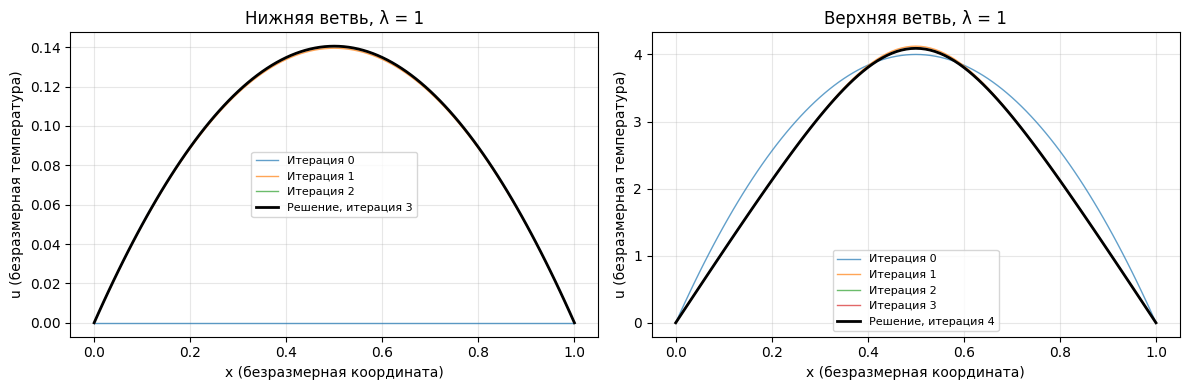

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, result, title in zip(axes, [low, high], ["Нижняя ветвь", "Верхняя ветвь"]):
    for k, U in enumerate(result["profiles"][:-1]):
        ax.plot(x, np.r_[0.0, U, 0.0], alpha=0.7, linewidth=1, label=f"Итерация {k}")
    ax.plot(x, np.r_[0.0, result["u"], 0.0], color="black", linewidth=2,
            label=f"Решение, итерация {len(result['residuals'])-1}")
    ax.set(xlabel="x (безразмерная координата)", ylabel="u (безразмерная температура)",
           title=f"{title}, λ = {Lambda:g}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Для достаточно близкого старта и невырожденного якобиана у решения метод Ньютона имеет локальную квадратичную сходимость. Но малое число шагов само по себе не доказывает порядок сходимости, а невязка и ошибка решения — разные величины.

На следующем графике показана норма невязки. Ошибку решения проверим отдельно по точной формуле.

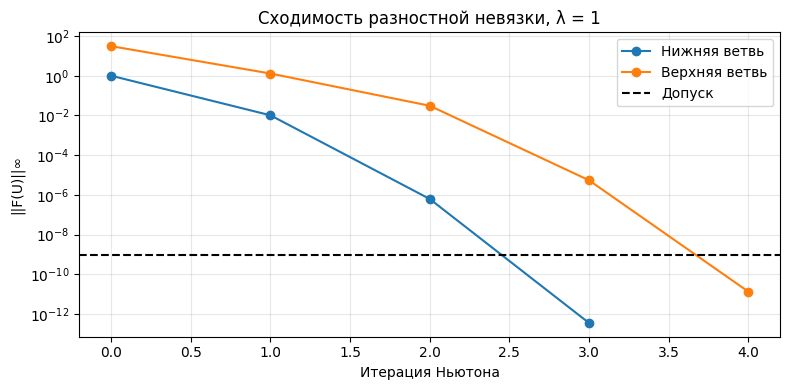

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, result in [("Нижняя ветвь", low), ("Верхняя ветвь", high)]:
    values = result["residuals"]
    ax.semilogy(np.arange(len(values)), np.where(values > 0, values, np.nan),
                "o-", label=label)
ax.axhline(RootTol, color="black", linestyle="--", label="Допуск")
ax.set(xlabel="Итерация Ньютона", ylabel="||F(U)||∞", title="Сходимость разностной невязки, λ = 1")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Точное семейство для независимой проверки

Для $a>0$ рассмотрим

$$u_a(x)=2\ln\frac{\cosh(a/2)}{\cosh\!\left(a(x-\tfrac12)\right)}.$$

Оно удовлетворяет нулевым граничным условиям, а

$$u_a''=-\frac{2a^2}{\cosh^2\!\left(a(x-\tfrac12)\right)},\qquad
e^{u_a}=\frac{\cosh^2(a/2)}{\cosh^2\!\left(a(x-\tfrac12)\right)}.$$

Значит, это решение при

$$\lambda(a)=\frac{2a^2}{\cosh^2(a/2)}.$$

Производная $\lambda(a)$ обращается в нуль при $a\tanh(a/2)=2$. Эта точка задаёт максимум $\lambda_*\approx3.51383$. При $0<\lambda<\lambda_*$ есть две положительные величины $a$, соответствующие двум ветвям; при $\lambda=\lambda_*$ ветви сливаются. При $\lambda>\lambda_*$ классических решений этой краевой задачи нет.

Для вычисления эталона решим скалярное уравнение относительно $a$. Этот способ проверки использует специальную точную формулу; основной алгоритм Ньютона выше о ней ничего не знает.

In [26]:
def logcosh(z):
    """Устойчивая запись log(cosh(z)), без переполнения cosh на больших z."""
    z = np.abs(np.asarray(z))
    return z + np.log1p(np.exp(-2*z)) - np.log(2.0)


def lambda_from_a(a):
    a = np.asarray(a)
    return 2*a**2 * np.exp(-2*logcosh(a/2))


a_critical = brentq(lambda a: a*np.tanh(a/2) - 2.0, 1.0, 4.0)
lambda_critical = float(lambda_from_a(a_critical))


def exact_parameter(lam, branch):
    if not 0 < lam < lambda_critical:
        raise ValueError("Две отдельные ветви определены при 0 < lam < lambda_critical")
    f = lambda a: lambda_from_a(a) - lam
    if branch == "low":
        return brentq(f, 0.0, a_critical, xtol=1e-13)
    if branch == "high":
        right = 2*a_critical
        while f(right) > 0:
            right *= 2
        return brentq(f, a_critical, right, xtol=1e-13)
    raise ValueError("branch должно быть 'low' или 'high'")


def exact_profile(grid, a):
    return 2*(logcosh(a/2) - logcosh(a*(np.asarray(grid)-0.5)))


a_low = exact_parameter(Lambda, "low")
a_high = exact_parameter(Lambda, "high")
print(f"Критический параметр непрерывной задачи: λ* = {lambda_critical:.10f}")
for label, result, a in [("Нижняя", low, a_low), ("Верхняя", high, a_high)]:
    error = np.max(np.abs(result["u"] - exact_profile(x[1:-1], a)))
    print(f"{label} ветвь: точный максимум = {exact_profile(0.5, a):.8f}, "
          f"максимальная ошибка на узлах = {error:.3e}")

Критический параметр непрерывной задачи: λ* = 3.5138307191
Нижняя ветвь: точный максимум = 0.14053921, максимальная ошибка на узлах = 1.423e-06
Верхняя ветвь: точный максимум = 4.09146725, максимальная ошибка на узлах = 2.720e-04


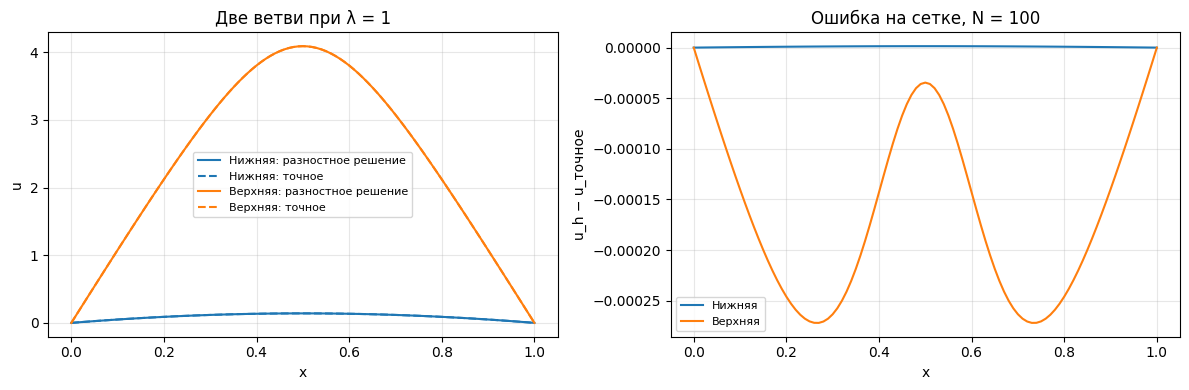

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, result, a in [("Нижняя", low, a_low), ("Верхняя", high, a_high)]:
    numerical = np.r_[0.0, result["u"], 0.0]
    reference = exact_profile(x, a)
    line, = axes[0].plot(x, numerical, label=f"{label}: разностное решение")
    axes[0].plot(x, reference, "--", color=line.get_color(), label=f"{label}: точное")
    axes[1].plot(x, numerical-reference, color=line.get_color(), label=label)
axes[0].set(xlabel="x", ylabel="u", title="Две ветви при λ = 1")
axes[1].set(xlabel="x", ylabel="u_h − u_точное", title=f"Ошибка на сетке, N = {N}")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Ошибка нелинейного решения и ошибка разностной схемы

Ньютон решает систему на **фиксированной сетке**. Даже почти нулевая невязка не устраняет ошибку замены производной разностью.

Для гладкого решения центральная разность второй производной имеет погрешность $O(h^2)$. Проверим второй порядок сходимости решения на обеих ветвях при $\lambda=1$, вдали от точки слияния. На каждой сетке заново решаем нелинейную систему и считаем

$$E_N=\max_i|u_i-u_*(x_i)|,\qquad
p_N=\log_2(E_N/E_{2N}).$$

Допуск относится к невязке, содержащей деление на $h^2$. Если умножить уравнения на $h^2$, их корни сохранятся, но прежнее численное значение допуска будет иметь другой смысл.


Нижняя ветвь
    N    max ошибка u        ||F||∞   порядок
   20      3.5604e-05     1.532e-14         —
   40      8.8956e-06     7.883e-14     2.001
   80      2.2236e-06     2.587e-13     2.000
  160      5.5588e-07     1.176e-12     2.000
  320      1.3897e-07     4.854e-12     2.000

Верхняя ветвь
    N    max ошибка u        ||F||∞   порядок
   20      6.8358e-03     1.009e-12         —
   40      1.7012e-03     1.613e-12     2.007
   80      4.2517e-04     8.939e-12     2.000
  160      1.0623e-04     2.989e-11     2.001
  320      2.6561e-05     1.210e-10     2.000


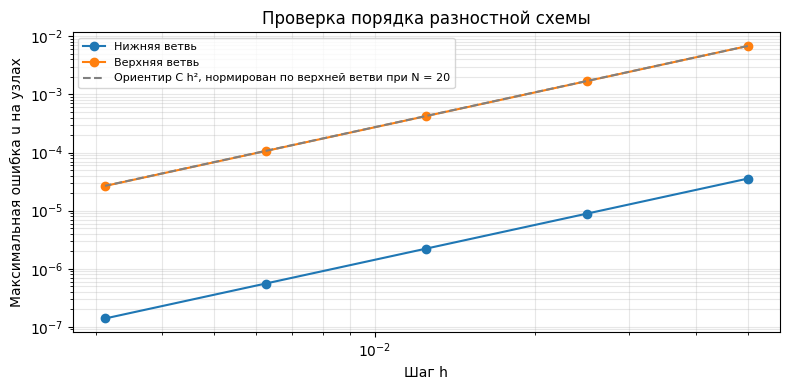

In [28]:
Refinement = {"low": [], "high": []}
for intervals in [20, 40, 80, 160, 320]:
    grid = np.linspace(0.0, 1.0, intervals + 1)
    for branch, a in [("low", a_low), ("high", a_high)]:
        start = (np.zeros(intervals-1) if branch == "low"
                 else 16*grid[1:-1]*(1-grid[1:-1]))
        result = newton(start, Lambda)
        error = np.max(np.abs(result["u"] - exact_profile(grid[1:-1], a)))
        Refinement[branch].append((intervals, error, result["residuals"][-1]))

for branch, label in [("low", "Нижняя ветвь"), ("high", "Верхняя ветвь")]:
    rows = np.array(Refinement[branch])
    print("\n" + label)
    print(f"{'N':>5} {'max ошибка u':>15} {'||F||∞':>13} {'порядок':>9}")
    for i, (intervals, error, norm) in enumerate(rows):
        order = "—" if i == 0 else f"{np.log2(rows[i-1, 1]/error):.3f}"
        print(f"{int(intervals):5d} {error:15.4e} {norm:13.3e} {order:>9}")

fig, ax = plt.subplots(figsize=(8, 4))
for branch, label in [("low", "Нижняя ветвь"), ("high", "Верхняя ветвь")]:
    rows = np.array(Refinement[branch])
    ax.loglog(1/rows[:, 0], rows[:, 1], "o-", label=label)
rows = np.array(Refinement["high"])
ax.loglog(1/rows[:, 0], rows[0, 1]*(rows[0, 0]/rows[:, 0])**2, "--",
          color="gray", label="Ориентир C h², нормирован по верхней ветви при N = 20")
ax.set(xlabel="Шаг h", ylabel="Максимальная ошибка u на узлах", title="Проверка порядка разностной схемы")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 8. Бонус: продолжение по параметру и слияние ветвей

Возьмём найденные решения при $\lambda=1$. Будем понемногу увеличивать параметр, каждый раз используя предыдущее решение как начальный профиль. Это простейшее продолжение по параметру.

Используем уменьшение шага Ньютона при необходимости. Остановимся при $\lambda=3.50$, немного раньше критического значения. Обычное продолжение по $\lambda$ не предназначено для прохождения точки поворота; для этого нужен другой параметр продолжения или метод псевдодлины дуги.

В точке слияния линейная задача для поправки вырождается. Посмотрим на минимальный модуль собственного значения симметричного якобиана. Его приближение к нулю указывает на близость к вырождению. Критический параметр разностной задачи немного отличается от непрерывного и зависит от сетки.

**Важно:** отказ Ньютона сам по себе не доказывает отсутствия решения. Утверждение о числе решений здесь опирается на точное семейство.

low: λ = 3.50, max u = 1.085780, min |eig(J)| = 8.694e-01
high: λ = 3.50, max u = 1.293818, min |eig(J)| = 9.274e-01


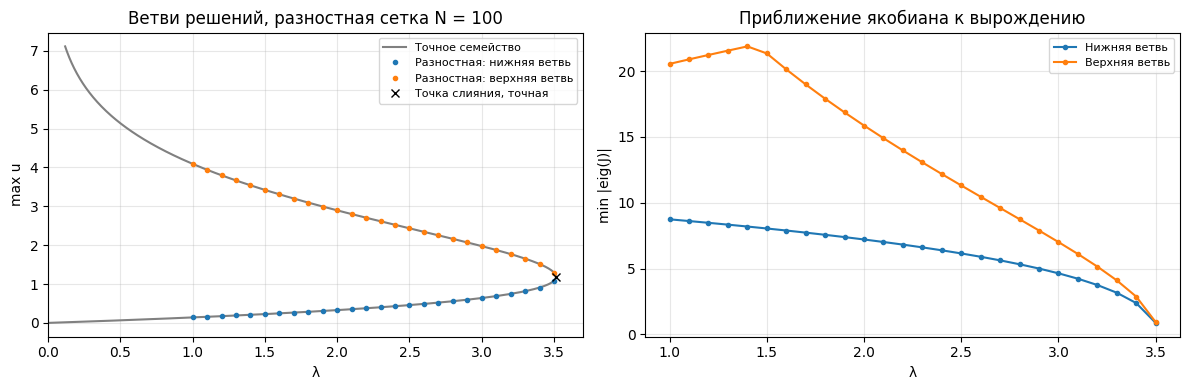

In [29]:
Continuation = {}
ParameterGrid = np.linspace(1.0, 3.50, 26)

for branch, initial in [("low", low["u"]), ("high", high["u"])]:
    U = initial.copy()
    rows = []
    for lam in ParameterGrid:
        result = newton(U, lam, damping=True)
        U = result["u"]
        smallest_eigenvalue = np.min(np.abs(np.linalg.eigvalsh(jacobian(U, lam))))
        rows.append((lam, np.max(U), smallest_eigenvalue, result["residuals"][-1]))
    Continuation[branch] = np.array(rows)
    print(f"{branch}: λ = {lam:.2f}, max u = {np.max(U):.6f}, "
          f"min |eig(J)| = {smallest_eigenvalue:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
a_grid = np.linspace(0.01, 8.5, 500)
axes[0].plot(lambda_from_a(a_grid), 2*logcosh(a_grid/2), color="gray",
             label="Точное семейство")
for branch, label in [("low", "Нижняя ветвь"), ("high", "Верхняя ветвь")]:
    rows = Continuation[branch]
    axes[0].plot(rows[:, 0], rows[:, 1], ".", label=f"Разностная: {label.lower()}")
    axes[1].plot(rows[:, 0], rows[:, 2], "o-", markersize=3, label=label)
axes[0].plot(lambda_critical, exact_profile(0.5, a_critical), "kx", label="Точка слияния, точная")
axes[0].set(xlabel="λ", ylabel="max u", title=f"Ветви решений, разностная сетка N = {N}", xlim=(0, 3.7))
axes[1].set(xlabel="λ", ylabel="min |eig(J)|", title="Приближение якобиана к вырождению")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. Ньютон в пространстве функций

Можно сначала линеаризовать дифференциальное уравнение, а потом построить разностную схему. Положим $u_{k+1}=u_k+\delta u$ и отбросим члены второго и более высоких порядков по поправке:

$$
\left\{
\begin{aligned}
\delta u''+\lambda e^{u_k}\delta u&=-\left(u_k''+\lambda e^{u_k}\right),\\
\delta u(0)&=0,\\
\delta u(1)&=0.
\end{aligned}
\right.
$$

На каждом шаге получается **линейная краевая задача для поправки к функции**. Если применить ту же центральную разностную схему, получим ровно систему $J(U_k)\Delta U=-F(U_k)$.

Это связывает многомерную формулу Ньютона с задачей поиска функции на отрезке. В пространстве сеточных значений дифференциальный оператор заменяется матрицей.

## Вопросы и дальнейшие опыты

1. Почему нулевой начальный профиль не является решением при $\lambda>0$, хотя он удовлетворяет обоим граничным условиям?
2. Почему почти нулевая разностная невязка не означает столь же малую ошибку относительно решения ОДУ?
3. Возьмите семейство начальных профилей $u^{(0)}=4A x(1-x)$ и меняйте $A$. Какие старты приводят к каждой ветви, а какие — к отказу? Сравните полный шаг и уменьшение шага Ньютона. Это сечение области сходимости в пространстве начальных профилей.
4. Проверьте якобиан направленной разностью: сравните $J(U)v$ с $[F(U+\varepsilon v)-F(U-\varepsilon v)]/(2\varepsilon)$ при разных $\varepsilon$.
5. Замените плотную матрицу на три диагонали и сравните время и память на больших сетках.
6. Исследуйте, как меняется поведение метода при приближении к критическому параметру. Отличайте трудности алгоритма от отсутствия решения.

Сходимость итераций Ньютона к профилю не устанавливает физическую устойчивость температурного режима. Для неё нужно отдельно исследовать нестационарную модель.

## Источники

- [Пример задачи Брату с двумя решениями в документации SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html). Здесь он используется для сопоставления постановки; наш алгоритм явно строит разностную систему и якобиан.
- [Пример PETSc: семейство задач Bratu и модель воспламенения](https://www.mcs.anl.gov/petsc/petsc-3.12/src/snes/examples/tutorials/ex15.c.html).

Точное семейство и его связь с параметром проверяются подстановкой в разделе 6.